In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/covid_indonesia.csv")
df.head()

,date,cases,deaths,recovered
0,2020-01-22,0,0,0
1,2020-01-23,0,0,0
2,2020-01-24,0,0,0
3,2020-01-25,0,0,0
4,2020-01-26,0,0,0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       1143 non-null   object
 1   cases      1143 non-null   int64 
 2   deaths     1143 non-null   int64 
 3   recovered  1143 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 35.8+ KB


,cases,deaths,recovered
count,1.143000e+03,1143.000000,1.143000e+03
mean,3.230452e+06,87782.764654,3.184099e+05
std,2.603756e+06,67241.540754,6.092008e+05
min,0.000000e+00,0.000000,0.000000e+00
25%,4.168885e+05,14095.000000,0.000000e+00
50%,3.854354e+06,117588.000000,0.000000e+00
75%,6.054034e+06,156569.000000,3.030530e+05
max,6.738225e+06,160941.000000,2.907920e+06


In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df["daily_cases"] = df["cases"].diff().fillna(0)
df["daily_deaths"] = df["deaths"].diff().fillna(0)
df["daily_recovered"] = df["recovered"].diff().fillna(0)

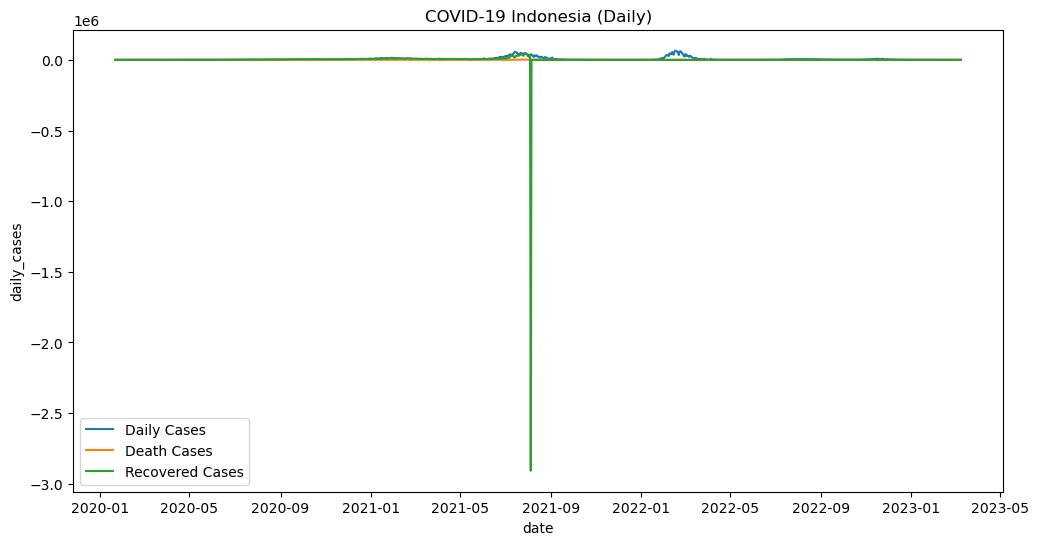

In [6]:
plt.figure(figsize=(12,6))
sns.lineplot(x="date", y="daily_cases", data=df, label="Daily Cases")
sns.lineplot(x="date", y="daily_deaths", data=df, label="Death Cases")
sns.lineplot(x="date", y="daily_recovered", data=df, label="Recovered Cases")
plt.legend()
plt.title("COVID-19 Indonesia (Daily)")
plt.show()

In [7]:
df.to_csv("../data/processed/covid_indonesia_processed.csv", index=False)